# Evaluation of brain age predictions in healthy subjects

This notebook visualizes model predictions for healthy subjects from the test set. Both the unsmoothed and smoothed models are evaluated, and raw predictions are compared with bias-corrected predictions.

In [1]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from scipy.stats import gaussian_kde

In [2]:
# Define paths to prediction files from the unsmoothed and smoothed models
unsmooth_predictions = Path("/Users/anneaasengen/MS_project/healthy_predictions/healthy_predictions.csv")
smooth_predictions = Path("/Users/anneaasengen/MS_project/healthy_predictions/smoothed_healthy_predictions.csv")

In [3]:
# Load predictions from both models into separate dataframes
# These files contain chronological age, predicted age, bias-corrected predicted age, and prediction errors.
df_unsmooth = pd.read_csv(unsmooth_predictions)
df_smooth = pd.read_csv(smooth_predictions)

# Inspect the first rows of the unsmoothed model predictions
df_unsmooth.head()

,image_path,participant_id,age,sex,dataset,predicted_age,predicted_age_bc,error_raw,abs_error_raw,error_bc,abs_error_bc
0,/home/anneaasengen/fastMONAI/data_asymmetry/as...,sub-211720,32.0,M,HCP,35.578600,35.941396,3.578602,3.578602,3.941396,3.941396
1,/home/anneaasengen/fastMONAI/data_asymmetry/as...,sub-CC420462,55.7,F,CamCAN,55.188133,55.270423,-0.511867,0.511867,-0.429577,0.429577
2,/home/anneaasengen/fastMONAI/data_asymmetry/as...,sub-CC520287,60.4,F,CamCAN,59.674103,59.692223,-0.725897,0.725897,-0.707777,0.707777
3,/home/anneaasengen/fastMONAI/data_asymmetry/as...,sub-CC310361,43.5,F,CamCAN,46.637344,46.841949,3.137344,3.137344,3.341949,3.341949
4,/home/anneaasengen/fastMONAI/data_asymmetry/as...,sub-CC520002,64.8,F,CamCAN,62.693268,62.668200,-2.106732,2.106732,-2.131800,2.131800


In [4]:
# Inspect the first rows of the smoothed model predictions
df_smooth.head()

,image_path,participant_id,age,sex,dataset,predicted_age,predicted_age_bc,error_raw,abs_error_raw,error_bc,abs_error_bc
0,/home/anneaasengen/fastMONAI/data_asymmetry/sm...,sub-211720,32.0,M,HCP,36.518345,37.171766,4.518345,4.518345,5.171766,5.171766
1,/home/anneaasengen/fastMONAI/data_asymmetry/sm...,sub-CC420462,55.7,F,CamCAN,59.114250,59.369872,3.414250,3.414250,3.669872,3.669872
2,/home/anneaasengen/fastMONAI/data_asymmetry/sm...,sub-CC520287,60.4,F,CamCAN,53.930874,54.277749,-6.469126,6.469126,-6.122251,6.122251
3,/home/anneaasengen/fastMONAI/data_asymmetry/sm...,sub-CC310361,43.5,F,CamCAN,51.279260,51.672815,7.779259,7.779259,8.172815,8.172815
4,/home/anneaasengen/fastMONAI/data_asymmetry/sm...,sub-CC520002,64.8,F,CamCAN,68.738945,68.825125,3.938945,3.938945,4.025125,4.025125


## Plot: Predicted vs cronological age

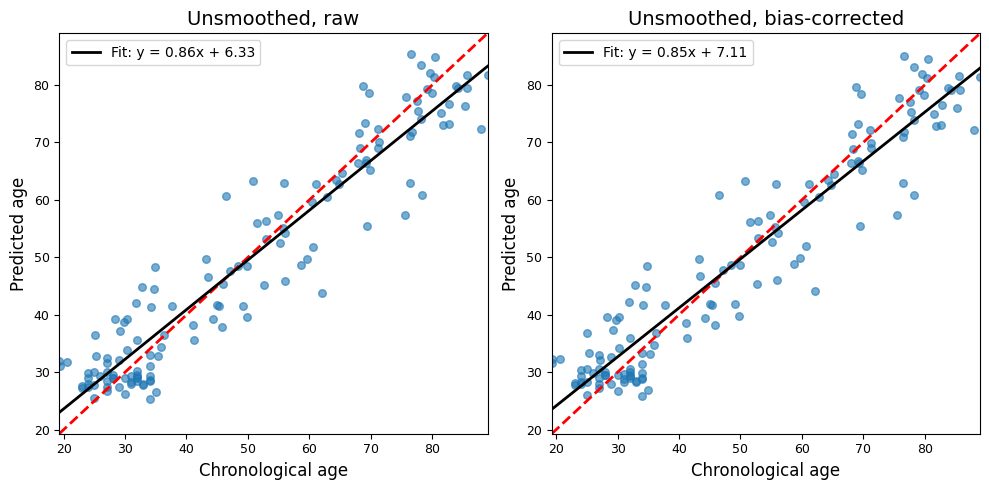

In [5]:
# Create side-by-side plots for unsmoothed predictions
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

title_fs = 14
legend_fs = 10
tick_fs = 9
axislabel_fs = 12

# Common axis limits
min_age = df_unsmooth["age"].min()

max_age = max(
    df_unsmooth["predicted_age"].max(),
    df_unsmooth["predicted_age_bc"].max(),
    df_unsmooth["age"].max()
)

#  Raw predictions 
ax = axes[0]

ax.scatter(
    df_unsmooth["age"],
    df_unsmooth["predicted_age"],
    alpha=0.6,
    s=30
)

ax.plot(
    [min_age, max_age],
    [min_age, max_age],
    'r--',
    linewidth=2
)

coef = np.polyfit(
    df_unsmooth["age"],
    df_unsmooth["predicted_age"],
    1
)

x_line = np.linspace(min_age, max_age, 100)
y_fit = coef[0] * x_line + coef[1]

ax.plot(
    x_line,
    y_fit,
    'k-',
    linewidth=2,
    label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}"
)

ax.set_title("Unsmoothed, raw", fontsize=title_fs)
ax.set_xlabel("Chronological age", fontsize=axislabel_fs)
ax.set_ylabel("Predicted age", fontsize=axislabel_fs)

ax.set_xlim(min_age, max_age)
ax.set_ylim(min_age, max_age)

ax.tick_params(axis='both', labelsize=tick_fs)
ax.legend(fontsize=legend_fs)

#  Bias-corrected predictions 
ax = axes[1]

ax.scatter(
    df_unsmooth["age"],
    df_unsmooth["predicted_age_bc"],
    alpha=0.6,
    s=30
)

ax.plot(
    [min_age, max_age],
    [min_age, max_age],
    'r--',
    linewidth=2
)

coef = np.polyfit(
    df_unsmooth["age"],
    df_unsmooth["predicted_age_bc"],
    1
)

y_fit = coef[0] * x_line + coef[1]

ax.plot(
    x_line,
    y_fit,
    'k-',
    linewidth=2,
    label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}"
)

ax.set_title("Unsmoothed, bias-corrected", fontsize=title_fs)
ax.set_xlabel("Chronological age", fontsize=axislabel_fs)
ax.set_ylabel("Predicted age", fontsize=axislabel_fs)

ax.set_xlim(min_age, max_age)
ax.set_ylim(min_age, max_age)

ax.tick_params(axis='both', labelsize=tick_fs)
ax.legend(fontsize=legend_fs)

plt.tight_layout()
plt.show()

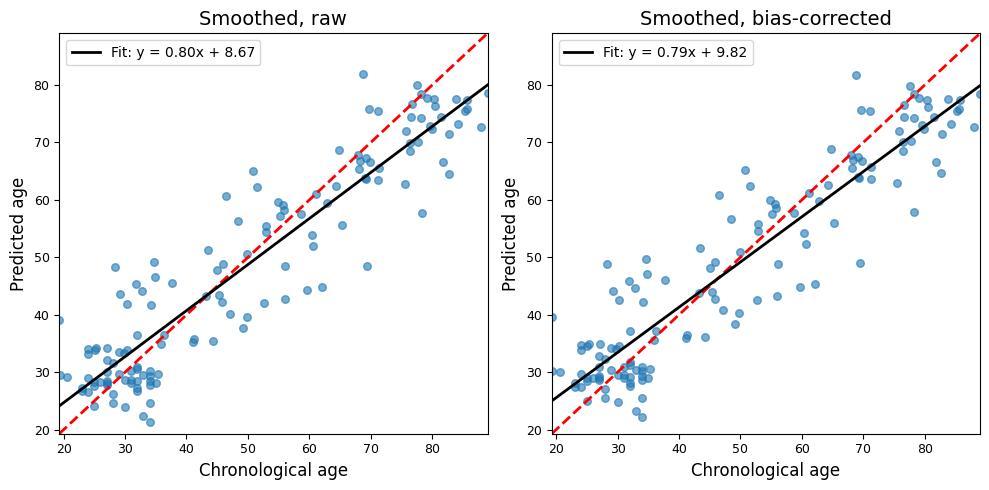

In [6]:
# Create side-by-side plots for smoothed predictions
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

title_fs = 14
legend_fs = 10
tick_fs = 9
axislabel_fs = 12

# Common axis limits
min_age = df_smooth["age"].min()

max_age = max(
    df_smooth["predicted_age"].max(),
    df_smooth["predicted_age_bc"].max(),
    df_smooth["age"].max()
)

#  Raw predictions 
ax = axes[0]

ax.scatter(
    df_smooth["age"],
    df_smooth["predicted_age"],
    alpha=0.6,
    s=30
)

ax.plot(
    [min_age, max_age],
    [min_age, max_age],
    'r--',
    linewidth=2
)

coef = np.polyfit(
    df_smooth["age"],
    df_smooth["predicted_age"],
    1
)

x_line = np.linspace(min_age, max_age, 100)
y_fit = coef[0] * x_line + coef[1]

ax.plot(
    x_line,
    y_fit,
    'k-',
    linewidth=2,
    label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}"
)

ax.set_title("Smoothed, raw", fontsize=title_fs)
ax.set_xlabel("Chronological age", fontsize=axislabel_fs)
ax.set_ylabel("Predicted age", fontsize=axislabel_fs)

ax.set_xlim(min_age, max_age)
ax.set_ylim(min_age, max_age)

ax.tick_params(axis='both', labelsize=tick_fs)
ax.legend(fontsize=legend_fs)

#  Bias-corrected predictions 
ax = axes[1]

ax.scatter(
    df_smooth["age"],
    df_smooth["predicted_age_bc"],
    alpha=0.6,
    s=30
)

ax.plot(
    [min_age, max_age],
    [min_age, max_age],
    'r--',
    linewidth=2
)

coef = np.polyfit(
    df_smooth["age"],
    df_smooth["predicted_age_bc"],
    1
)

y_fit = coef[0] * x_line + coef[1]

ax.plot(
    x_line,
    y_fit,
    'k-',
    linewidth=2,
    label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}"
)

ax.set_title("Smoothed, bias-corrected", fontsize=title_fs)
ax.set_xlabel("Chronological age", fontsize=axislabel_fs)
ax.set_ylabel("Predicted age", fontsize=axislabel_fs)

ax.set_xlim(min_age, max_age)
ax.set_ylim(min_age, max_age)

ax.tick_params(axis='both', labelsize=tick_fs)
ax.legend(fontsize=legend_fs)

plt.tight_layout()
plt.show()

## Plot: Prediction error vs cronological age

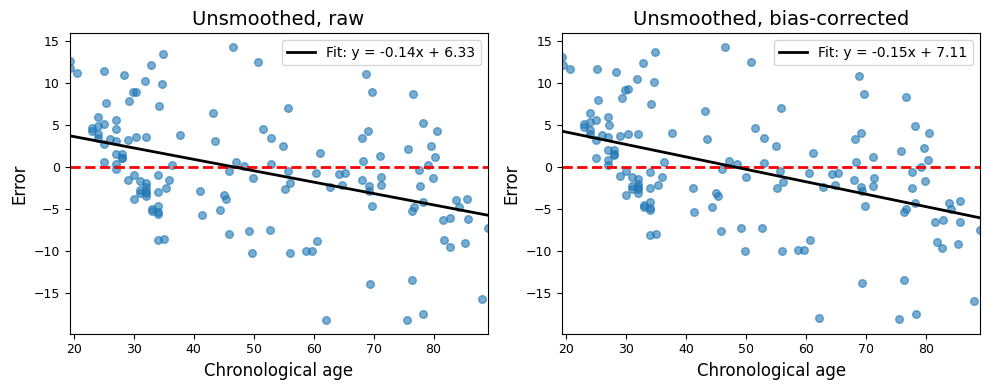

In [7]:
# Use common axis limits for the two unsmoothed plots
min_age = df_unsmooth["age"].min()
max_age = df_unsmooth["age"].max()

min_err = min(
    df_unsmooth["error_raw"].min(),
    df_unsmooth["error_bc"].min()
)

max_err = max(
    df_unsmooth["error_raw"].max(),
    df_unsmooth["error_bc"].max()
)

# Add a small margin so points do not lie directly on the plot borders
y_margin = 0.05 * (max_err - min_err)
lower_lim = min_err - y_margin
upper_lim = max_err + y_margin

# Create side-by-side plots for unsmoothed prediction errors
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

title_fs = 14
legend_fs = 10
tick_fs = 9
axislabel_fs = 12

# Unsmoothed, raw
ax = axes[0]
ax.scatter(df_unsmooth["age"], df_unsmooth["error_raw"], alpha=0.6, s=30)

ax.axhline(0, color='r', linestyle='--', linewidth=2)

x_line = np.linspace(min_age, max_age, 100)
coef = np.polyfit(df_unsmooth["age"], df_unsmooth["error_raw"], 1)
y_fit = coef[0] * x_line + coef[1]

ax.plot(
    x_line,
    y_fit,
    'k-',
    label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}",
    linewidth=2
)

ax.set_title("Unsmoothed, raw", fontsize=title_fs)
ax.set_xlabel("Chronological age", fontsize=axislabel_fs)
ax.set_ylabel("Error", fontsize=axislabel_fs)
ax.set_xlim(min_age, max_age)
ax.set_ylim(lower_lim, upper_lim)
ax.tick_params(axis='both', labelsize=tick_fs)
ax.legend(fontsize=legend_fs)

# Unsmoothed, bias-corrected
ax = axes[1]
ax.scatter(df_unsmooth["age"], df_unsmooth["error_bc"], alpha=0.6, s=30)

ax.axhline(0, color='r', linestyle='--', linewidth=2)

coef = np.polyfit(df_unsmooth["age"], df_unsmooth["error_bc"], 1)
y_fit = coef[0] * x_line + coef[1]

ax.plot(
    x_line,
    y_fit,
    'k-',
    label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}",
    linewidth=2
)

ax.set_title("Unsmoothed, bias-corrected", fontsize=title_fs)
ax.set_xlabel("Chronological age", fontsize=axislabel_fs)
ax.set_ylabel("Error", fontsize=axislabel_fs)
ax.set_xlim(min_age, max_age)
ax.set_ylim(lower_lim, upper_lim)
ax.tick_params(axis='both', labelsize=tick_fs)
ax.legend(fontsize=legend_fs)

plt.tight_layout()
plt.show()

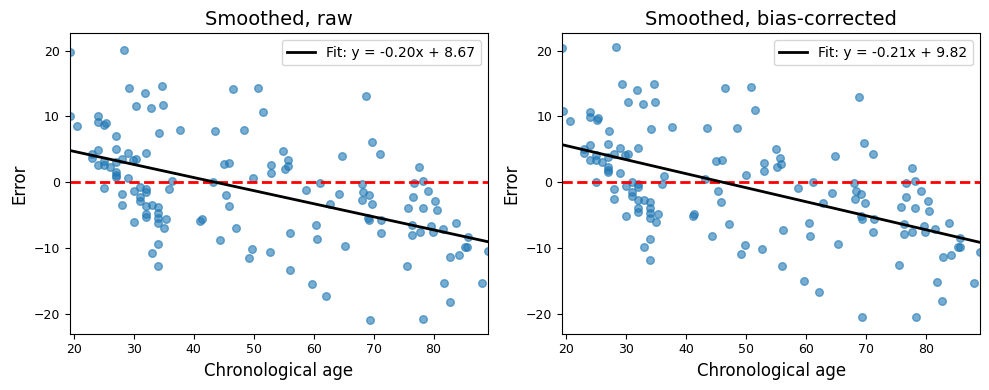

In [8]:
# Use common axis limits for the two smoothed plots
min_age = df_smooth["age"].min()
max_age = df_smooth["age"].max()

min_err = min(
    df_smooth["error_raw"].min(),
    df_smooth["error_bc"].min()
)

max_err = max(
    df_smooth["error_raw"].max(),
    df_smooth["error_bc"].max()
)

# Add a small margin so points do not lie directly on the plot borders
y_margin = 0.05 * (max_err - min_err)
lower_lim = min_err - y_margin
upper_lim = max_err + y_margin

# Create side-by-side plots for smoothed prediction errors
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

title_fs = 14
legend_fs = 10
tick_fs = 9
axislabel_fs = 12

# Smoothed, raw
ax = axes[0]
ax.scatter(df_smooth["age"], df_smooth["error_raw"], alpha=0.6, s=30)

ax.axhline(0, color='r', linestyle='--', linewidth=2)

x_line = np.linspace(min_age, max_age, 100)
coef = np.polyfit(df_smooth["age"], df_smooth["error_raw"], 1)
y_fit = coef[0] * x_line + coef[1]

ax.plot(
    x_line,
    y_fit,
    'k-',
    label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}",
    linewidth=2
)

ax.set_title("Smoothed, raw", fontsize=title_fs)
ax.set_xlabel("Chronological age", fontsize=axislabel_fs)
ax.set_ylabel("Error", fontsize=axislabel_fs)
ax.set_xlim(min_age, max_age)
ax.set_ylim(lower_lim, upper_lim)
ax.tick_params(axis='both', labelsize=tick_fs)
ax.legend(fontsize=legend_fs)

# Smoothed, bias-corrected
ax = axes[1]
ax.scatter(df_smooth["age"], df_smooth["error_bc"], alpha=0.6, s=30)

ax.axhline(0, color='r', linestyle='--', linewidth=2)

coef = np.polyfit(df_smooth["age"], df_smooth["error_bc"], 1)
y_fit = coef[0] * x_line + coef[1]

ax.plot(
    x_line,
    y_fit,
    'k-',
    label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}",
    linewidth=2
)

ax.set_title("Smoothed, bias-corrected", fontsize=title_fs)
ax.set_xlabel("Chronological age", fontsize=axislabel_fs)
ax.set_ylabel("Error", fontsize=axislabel_fs)
ax.set_xlim(min_age, max_age)
ax.set_ylim(lower_lim, upper_lim)
ax.tick_params(axis='both', labelsize=tick_fs)
ax.legend(fontsize=legend_fs)

plt.tight_layout()
plt.show()

## Histogram: Error distribution

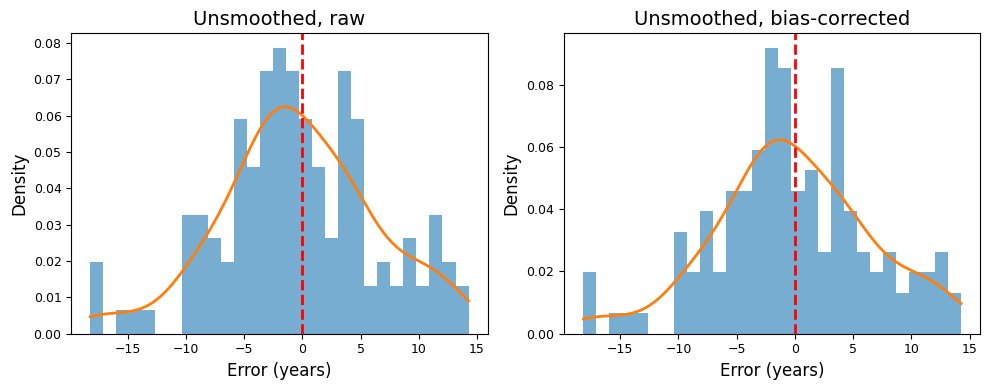

In [9]:
# Use common bins for the two unsmoothed histograms
all_errors_unsmooth = np.concatenate([
    df_unsmooth["error_raw"],
    df_unsmooth["error_bc"]
])

bins = np.linspace(all_errors_unsmooth.min(), all_errors_unsmooth.max(), 30)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

title_fs = 14
axislabel_fs = 12
tick_fs = 9

# Unsmoothed, raw
ax = axes[0]

data = df_unsmooth["error_raw"]

ax.hist(data, bins=bins, density=True, alpha=0.6)

kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 200)
ax.plot(x, kde(x), linewidth=2)

ax.axvline(0, color='r', linestyle='--', linewidth=2)

ax.set_title("Unsmoothed, raw", fontsize=title_fs)
ax.set_xlabel("Error (years)", fontsize=axislabel_fs)
ax.set_ylabel("Density", fontsize=axislabel_fs)
ax.tick_params(axis='both', labelsize=tick_fs)

# Unsmoothed, bias-corrected
ax = axes[1]

data = df_unsmooth["error_bc"]

ax.hist(data, bins=bins, density=True, alpha=0.6)

kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 200)
ax.plot(x, kde(x), linewidth=2)

ax.axvline(0, color='r', linestyle='--', linewidth=2)

ax.set_title("Unsmoothed, bias-corrected", fontsize=title_fs)
ax.set_xlabel("Error (years)", fontsize=axislabel_fs)
ax.set_ylabel("Density", fontsize=axislabel_fs)
ax.tick_params(axis='both', labelsize=tick_fs)

plt.tight_layout()
plt.show()

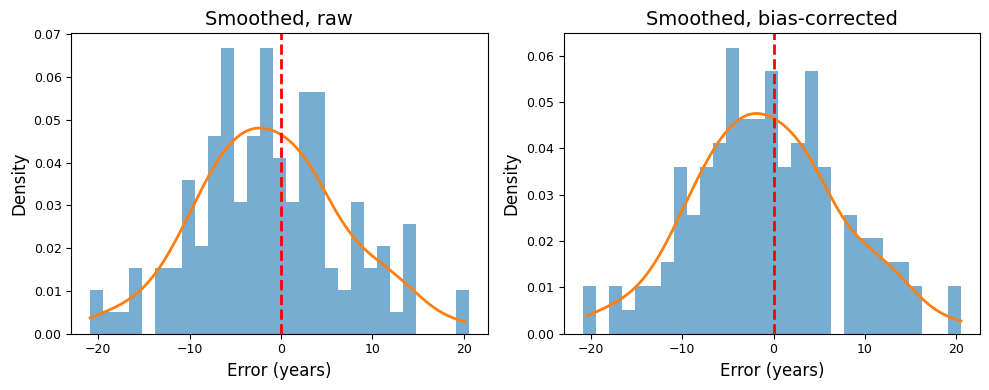

In [10]:
# Use common bins for the two smoothed histograms
all_errors_smooth = np.concatenate([
    df_smooth["error_raw"],
    df_smooth["error_bc"]
])

bins = np.linspace(all_errors_smooth.min(), all_errors_smooth.max(), 30)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

title_fs = 14
axislabel_fs = 12
tick_fs = 9

# Smoothed, raw
ax = axes[0]

data = df_smooth["error_raw"]

ax.hist(data, bins=bins, density=True, alpha=0.6)

kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 200)
ax.plot(x, kde(x), linewidth=2)

ax.axvline(0, color='r', linestyle='--', linewidth=2)

ax.set_title("Smoothed, raw", fontsize=title_fs)
ax.set_xlabel("Error (years)", fontsize=axislabel_fs)
ax.set_ylabel("Density", fontsize=axislabel_fs)
ax.tick_params(axis='both', labelsize=tick_fs)

# Smoothed, bias-corrected
ax = axes[1]

data = df_smooth["error_bc"]

ax.hist(data, bins=bins, density=True, alpha=0.6)

kde = gaussian_kde(data)
x = np.linspace(data.min(), data.max(), 200)
ax.plot(x, kde(x), linewidth=2)

ax.axvline(0, color='r', linestyle='--', linewidth=2)

ax.set_title("Smoothed, bias-corrected", fontsize=title_fs)
ax.set_xlabel("Error (years)", fontsize=axislabel_fs)
ax.set_ylabel("Density", fontsize=axislabel_fs)
ax.tick_params(axis='both', labelsize=tick_fs)

plt.tight_layout()
plt.show()

### Mean of error values

In [11]:
# Calculate mean prediction error for each model and correction method
# Positive values indicate overestimation of chronological age, while negative values indicate underestimation
mean_error_unsmoothed_raw = df_unsmooth["error_raw"].mean()
mean_error_unsmoothed_bc = df_unsmooth["error_bc"].mean()

mean_error_smoothed_raw = df_smooth["error_raw"].mean()
mean_error_smoothed_bc = df_smooth["error_bc"].mean()

print("Mean error:")
print("Unsmoothed, raw:", mean_error_unsmoothed_raw)
print("Unsmoothed, bias-corrected:", mean_error_unsmoothed_bc)
print("Smoothed, raw:", mean_error_smoothed_raw)
print("Smoothed, bias-corrected:", mean_error_smoothed_bc)

Mean error:
Unsmoothed, raw: -0.40212978194741616
Unsmoothed, bias-corrected: -0.23454173693184252
Smoothed, raw: -1.1793343796449545
Smoothed, bias-corrected: -0.7359317232605761
